In [1]:
#THINGS TO DO

#- CHART WITH THE MEAN VALUES
#- REPLACE THE 1.0 AND 2.0 VALUES OF GENDER

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/giovannimelo/venda-medicamentos-industrializados-controlados/EDA_Industrializados_202601.csv


In [3]:
# More libraries used
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Importing the dataset
df = pd.read_csv('/kaggle/input/datasets/giovannimelo/venda-medicamentos-industrializados-controlados/EDA_Industrializados_202601.csv', 
                 encoding='latin-1', 
                 sep = ';',
                low_memory=True)

/tmp/ipykernel_17/1351441495.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/kaggle/input/datasets/giovannimelo/venda-medicamentos-industrializados-controlados/EDA_Industrializados_202601.csv',


In [5]:
print('Number of Rows:', df.shape[0])
print('Number of Columns:', df.shape[1])
print('Number of Duplicated Values:', df.duplicated().sum())
print('Number of Missing Values:', df.isnull().sum())

Number of Rows: 4655128
Number of Columns: 15
Number of Duplicated Values: 0
Number of Missing Values: NU_ANO_VENDA                       0
NU_MES_VENDA                       0
SG_UF_VENDA                        2
NO_MUNICIPIO_VENDA                 0
DS_PRINCIPIO_ATIVO              1962
DS_DESCRICAO_APRESENTACAO          0
QT_VENDIDA                         0
DS_UNIDADE_MEDIDA                  0
NO_CONSELHO_PRESCRITOR             0
SG_UF_CONSELHO_PRESCRITOR          0
TP_RECEITUARIO                     0
CO_CID10                     4650759
SG_SEXO                      1576120
NU_IDADE                     1576120
NU_UNIDADE_IDADE             1576120
dtype: int64


In [6]:
# The columns NU_ANO_VENDA and NU_MES_VENDA could be dropped because this data it's only from January 2026
# Also, for now, I don't need the info about CO_CID10 (and this column have a high number of missing values)
df = df.drop(columns=['NU_ANO_VENDA', 'NU_MES_VENDA', 'CO_CID10'])

In [7]:
# Aleatory sample of the df (just for curiosity)
df.sample(10)

,SG_UF_VENDA,NO_MUNICIPIO_VENDA,DS_PRINCIPIO_ATIVO,DS_DESCRICAO_APRESENTACAO,QT_VENDIDA,DS_UNIDADE_MEDIDA,NO_CONSELHO_PRESCRITOR,SG_UF_CONSELHO_PRESCRITOR,TP_RECEITUARIO,SG_SEXO,NU_IDADE,NU_UNIDADE_IDADE
1782939,RS,ARROIO DO MEIO,AMOXICILINA TRIHIDRATADA + CLAVULANATO DE POTÁ...,"(875,0 + 125,0) MG COM REV CT ENVOL BL AL PLAS...",1,CAIXA,CRO,RS,5.0,2.0,126.0,1.0
2787504,SP,BARRINHA,CLORIDRATO DE TRAZODONA,100 MG COM REV CT BL AL PLAS PVC/PVDC 120 TRAN...,5,CAIXA,CRM,SP,1.0,NaN,NaN,NaN
4265093,MG,ANGELÂNDIA,CIPROFLOXACINO + HIDROCORTISONA MICRONIZADA,"2,0 MG + 10 MG/ML SUS OTO CT FR OPC GOT X 5 ML",2,FRASCO,CRM,MG,5.0,2.0,40.0,1.0
2822995,MS,CAMPO GRANDE,NITROFURANTOÍNA,100MG CAP GEL DURA CT BL AL PLAS TRANS X 28,1,CAIXA,CRM,MS,1.0,1.0,64.0,1.0
3974620,SP,TATUÍ,AMOXICILINA TRI-HIDRATADA + CLAVULANATO DE POT...,(875+ 125) MG COM REV CT ENVOL BL AL PLAS PVC/...,1,CAIXA,CRM,SP,5.0,1.0,7.0,1.0
2569388,SP,RIO CLARO,NITROFURANTOÍNA,100 MG CAP GEL DURA CT BL AL PLAS INC X 28,1,CAIXA,CRM,SP,5.0,2.0,45.0,1.0
302291,MG,VARGEM GRANDE DO RIO PARDO,AMOXICILINA TRI-HIDRATADA,50 MG/ML PO SUS OR CT FR PLAS OPC X 150 ML + COP,1,FRASCO,CRM,MG,5.0,2.0,2.0,1.0
2859804,SP,SANTOS,HIDROCORTISONA + SULFATO DE NEOMICINA + SULFAT...,(10 +5) MG/ML + 10.000 UI/ML SUSP OTO CT FR GO...,1,FRASCO,CRM,SP,5.0,1.0,61.0,1.0
1669185,SP,JARDINÓPOLIS,SULFAMETOXAZOL + TRIMETOPRIMA,400 MG + 80 MG COM CT BL AL PLAS TRANS X 20,2,CAIXA,CRM,SP,5.0,2.0,39.0,1.0
4427669,GO,APARECIDA DE GOIÂNIA,FOSFOMICINA TROMETAMOL,"5,631 G GRAN SOL OR CT ENV AL/PLAS PES/PE OPC",1,CAIXA,CRM,GO,5.0,1.0,52.0,1.0


In [8]:
# Filtering the Mounjaro (Tirzepatida) value of the dataset
filtered_df = df[df['DS_PRINCIPIO_ATIVO'].str.upper() == 'TIRZEPATIDA']
filtered_df.head()


,SG_UF_VENDA,NO_MUNICIPIO_VENDA,DS_PRINCIPIO_ATIVO,DS_DESCRICAO_APRESENTACAO,QT_VENDIDA,DS_UNIDADE_MEDIDA,NO_CONSELHO_PRESCRITOR,SG_UF_CONSELHO_PRESCRITOR,TP_RECEITUARIO,SG_SEXO,NU_IDADE,NU_UNIDADE_IDADE
2782,MS,CAMPO GRANDE,TIRZEPATIDA,15 MG/ML SOL INJ SC CT 4 SER PREENC VD TRANS X...,1,FRASCO,CRM,MS,5.0,2.0,53.0,1.0
2783,MS,CAMPO GRANDE,TIRZEPATIDA,15 MG/ML SOL INJ SC CT 4 SER PREENC VD TRANS X...,1,FRASCO,CRM,MS,5.0,2.0,54.0,1.0
2784,MS,CAMPO GRANDE,TIRZEPATIDA,15 MG/ML SOL INJ SC CT 4 SER PREENC VD TRANS X...,1,FRASCO,CRM,MS,5.0,2.0,55.0,1.0
2785,MS,CAMPO GRANDE,TIRZEPATIDA,15 MG/ML SOL INJ SC CT 4 SER PREENC VD TRANS X...,1,FRASCO,CRM,MS,5.0,2.0,60.0,1.0
2786,MS,CAMPO GRANDE,TIRZEPATIDA,15 MG/ML SOL INJ SC CT 4 SER PREENC VD TRANS X...,2,FRASCO,CRM,MS,5.0,2.0,61.0,1.0


In [9]:
filtered_df.count()

SG_UF_VENDA                  95259
NO_MUNICIPIO_VENDA           95259
DS_PRINCIPIO_ATIVO           95259
DS_DESCRICAO_APRESENTACAO    95259
QT_VENDIDA                   95259
DS_UNIDADE_MEDIDA            95259
NO_CONSELHO_PRESCRITOR       95259
SG_UF_CONSELHO_PRESCRITOR    95259
TP_RECEITUARIO               95259
SG_SEXO                      92350
NU_IDADE                     92350
NU_UNIDADE_IDADE             92350
dtype: int64

In [10]:
# Nice! Let's filter the UF and start some visual analysis to see the State where this medication was most bought
uf_state = filtered_df.groupby('SG_UF_VENDA')['QT_VENDIDA'].sum().sort_values(ascending=False)
uf_state.head()

SG_UF_VENDA
SP    94212
RJ    24886
MG    20325
PR    10358
SC     9943
Name: QT_VENDIDA, dtype: int64

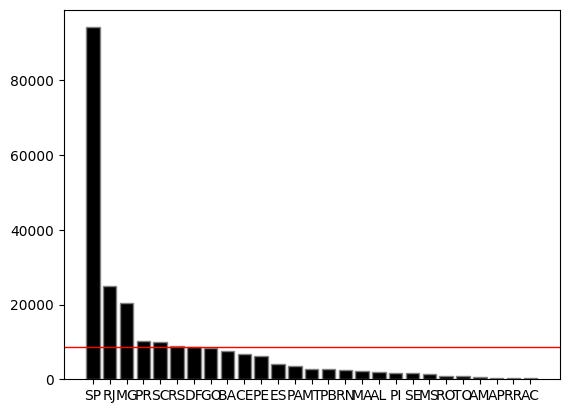

In [11]:
# Creating the bar chart using Matplotlib and adding a mean
uf_state_mean = uf_state.mean()
plt.bar(uf_state.index, uf_state.values, color='black', edgecolor='grey')

# Adding the mean line on the chart
plt.axhline (y=uf_state_mean, color='red', linestyle='-', linewidth=1, label=f'Mean: {uf_state_mean:,.2f}')

In [12]:
# Now let's see if there is more women or man using the Mounjaro in Brazil
# Replace SG_SEXO 1.0 = Man
# Replace SG_SEXO 2.0 = Women
filtered_df = filtered_df['SG_SEXO'].replace({1.0: 'Man', 2.0: 'Woman'})

